In [2]:
pip install matplotlib


  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 22.4 MB/s  0:00:00 23.8 MB/s eta 0:00:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 25.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 34.7 MB/s  0:00:00 38.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 41.7 MB/s  0:00:004.0 MB/s eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [6]:
# APPROACH 1: CORRECT LOSO PIPELINE
# Pipeline:
#   Outer LOSO -> Inner GroupKFold threshold tuning -> Retrain on ALL non-test -> Evaluate
#
# Leakage rules enforced:
#   - Scaler, SMOTE fit inside each fold only
#   - No global preprocessing before subject split
#   - Test subject never seen until final evaluation
#
# Imbalance: SMOTE + RandomUnderSampler only (class_weight removed)
# Metrics: Accuracy, F1, Balanced Accuracy, Recall, ROC-AUC, PR-AUC, Confusion Matrix

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    recall_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

print("="*90)
print("CORRECT LOSO PIPELINE -- Inner GroupKFold + Full Retrain + Metrics")
print("="*90)


CORRECT LOSO PIPELINE -- Inner GroupKFold + Full Retrain + Metrics


In [7]:
#load Data

print("\n[STEP 1] Loading Data...")
df = pd.read_csv('wesad_ml_ready.csv')

print(f"✓ Data loaded: {df.shape[0]} samples")
print(f"  Class distribution:")
print(f"    Non-Stress (0): {np.sum(df['label_binary']==0)} ({100*np.sum(df['label_binary']==0)/len(df):.1f}%)")
print(f"    Stress (1): {np.sum(df['label_binary']==1)} ({100*np.sum(df['label_binary']==1)/len(df):.1f}%)")



[STEP 1] Loading Data...
✓ Data loaded: 81442 samples
  Class distribution:
    Non-Stress (0): 64937 (79.7%)
    Stress (1): 16505 (20.3%)


In [8]:
# STEP 2: PREPARE FEATURES

print("\n[STEP 2] Preparing Features...")

feature_cols = [
    'ecg_mean', 'ecg_std', 'ecg_min', 'ecg_max',
    'eda_mean', 'eda_std', 'eda_min', 'eda_max', 'eda_slope',
    'emg_mean', 'emg_std', 'emg_rms',
    'resp_mean', 'resp_std', 'resp_range',
    'temp_mean', 'temp_std', 'temp_slope',
    'acc_x_mean', 'acc_y_mean', 'acc_z_mean', 'acc_magnitude'
]

X_all = df[feature_cols].values
y_all = df['label_binary'].values
subjects_all = df['subject'].values

print(f"✓ Features prepared: {X_all.shape}")
print(f"✓ Unique subjects: {len(np.unique(subjects_all))}")

unique_subjects = sorted(np.unique(subjects_all))



[STEP 2] Preparing Features...
✓ Features prepared: (81442, 22)
✓ Unique subjects: 15


In [9]:
# STEP 3: HELPER -- BALANCE TRAINING DATA
# Uses SMOTE then RandomUnderSampler.
# class_weight='balanced' is NOT used in the model (avoids double-correcting).
# k_neighbors is clipped safely to minority_count - 1.

def find_best_threshold(y_true, y_proba, metric='f1', threshold_range=np.arange(0.1, 0.9, 0.02)):
    """Find optimal threshold on validation data"""
    best_threshold = 0.5
    best_score = -1
    
    for threshold in threshold_range:
        y_pred = (y_proba >= threshold).astype(int)
        
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        else:
            score = accuracy_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

def balance_data(X, y):
    """SMOTE + RandomUnderSampler"""
    n_minority = np.sum(y == 1)
    
    # SMOTE only if we have enough samples
    if n_minority >= 4:
        try:
            smote = SMOTE(random_state=42, k_neighbors=3)
            X_smote, y_smote = smote.fit_resample(X, y)
        except:
            X_smote, y_smote = X, y
    else:
        X_smote, y_smote = X, y
    
    # Undersampling
    n_minority = np.sum(y_smote == 1)
    n_majority = np.sum(y_smote == 0)
    target_ratio = max(0.5, min(1.0, n_minority / n_majority))
    
    undersample = RandomUnderSampler(random_state=42, sampling_strategy=target_ratio)
    X_balanced, y_balanced = undersample.fit_resample(X_smote, y_smote)
    
    return X_balanced, y_balanced


In [12]:
# STEP 4: HELPER -- FIND BEST THRESHOLD
# Sweeps thresholds on aggregated out-of-fold validation probabilities.
# Optimises F1 by default.

def find_best_threshold(y_true, y_proba, metric='f1', threshold_range=np.arange(0.1, 0.9, 0.02)):
    """Find optimal threshold on validation data"""
    best_threshold = 0.5
    best_score = -1
    
    for threshold in threshold_range:
        y_pred = (y_proba >= threshold).astype(int)
        
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        else:
            score = accuracy_score(y_true, y_pred)
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score

def balance_data(X, y):
    """SMOTE + RandomUnderSampler"""
    n_minority = np.sum(y == 1)
    
    # SMOTE only if we have enough samples
    if n_minority >= 4:
        try:
            smote = SMOTE(random_state=42, k_neighbors=3)
            X_smote, y_smote = smote.fit_resample(X, y)
        except:
            X_smote, y_smote = X, y
    else:
        X_smote, y_smote = X, y
    
    # Undersampling
    n_minority = np.sum(y_smote == 1)
    n_majority = np.sum(y_smote == 0)
    target_ratio = max(0.5, min(1.0, n_minority / n_majority))
    
    undersample = RandomUnderSampler(random_state=42, sampling_strategy=target_ratio)
    X_balanced, y_balanced = undersample.fit_resample(X_smote, y_smote)
    
    return X_balanced, y_balanced

In [13]:
# verify Data
print("\n[STEP 3] Data Verification...")
print(f"✓ Total samples: {len(X_all)}")
print(f"✓ Total features: {X_all.shape[1]}")
print(f"✓ Total subjects: {len(unique_subjects)}")
print(f"  Subjects: {unique_subjects}")



[STEP 3] Data Verification...
✓ Total samples: 81442
✓ Total features: 22
✓ Total subjects: 15
  Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [14]:
# STEP 5: MAIN LOSO LOOP
# For each test subject:
#   A) Inner GroupKFold on remaining subjects -> collect OOF val probabilities
#   -> find best threshold on those aggregated OOF probabilities
#   B) Retrain FINAL model on ALL non-test subjects (scale + SMOTE inside fold)
#   C) Predict on test subject with locked threshold
#
# No data from the test subject is ever used before step C.

N_INNER_SPLITS = 5   # GroupKFold splits

print("\n[STEP 5] LOSO Training Loop")
print("="*90)

final_results = []
fold_cms = []

for fold_idx, test_subj in enumerate(unique_subjects, 1):
    
    # -- Outer split --
    test_mask = subjects_all == test_subj
    train_mask = ~test_mask
    
    X_train_pool = X_all[train_mask]
    y_train_pool = y_all[train_mask]
    g_train_pool = subjects_all[train_mask]  # subject labels for GroupKFold
    
    X_test = X_all[test_mask]
    y_test = y_all[test_mask]
    
    print(f"\n[FOLD {fold_idx}/{len(unique_subjects)}] Test subject: {test_subj} ({len(X_test)} samples)")
    
    # -- A) Inner GroupKFold: aggregate OOF for threshold tuning --
    n_inner = min(N_INNER_SPLITS, len(np.unique(g_train_pool)))
    gkf = GroupKFold(n_splits=n_inner)
    
    oof_proba = np.zeros(len(y_train_pool))
    oof_mask = np.zeros(len(y_train_pool), dtype=bool)
    
    for inner_tr_idx, inner_val_idx in gkf.split(X_train_pool, y_train_pool, groups=g_train_pool):
        X_itr = X_train_pool[inner_tr_idx]
        y_itr = y_train_pool[inner_tr_idx]
        X_ival = X_train_pool[inner_val_idx]
        
        # Scale inside inner fold only
        sc_inner = StandardScaler()
        X_itr_sc = sc_inner.fit_transform(X_itr)
        X_ival_sc = sc_inner.transform(X_ival)
        
        # Balance inner train
        X_itr_b, y_itr_b = balance_data(X_itr_sc, y_itr)
        
        # Train inner model
        m_inner = RandomForestClassifier(
            n_estimators=300, max_depth=20, random_state=42, n_jobs=-1
        )
        m_inner.fit(X_itr_b, y_itr_b)
        
        oof_proba[inner_val_idx] = m_inner.predict_proba(X_ival_sc)[:, 1]
        oof_mask[inner_val_idx] = True
    
    # Find threshold from OOF predictions
    optimal_threshold, inner_f1 = find_best_threshold(
        y_train_pool[oof_mask], oof_proba[oof_mask], metric='f1'
    )
    print(f"  Inner GKF ({n_inner} splits) -> threshold={optimal_threshold:.2f} (OOF F1={inner_f1:.4f})")
    
    # -- B) Retrain FINAL model on ALL non-test subjects --
    scaler_final = StandardScaler()
    X_train_sc = scaler_final.fit_transform(X_train_pool)
    X_test_sc = scaler_final.transform(X_test)
    
    X_train_b, y_train_b = balance_data(X_train_sc, y_train_pool)

    model_final = RandomForestClassifier(
        n_estimators=500, max_depth=25, random_state=42, n_jobs=-1
    )
    model_final.fit(X_train_b, y_train_b)
    
    # -- C) Evaluate on test subject --
    y_proba = model_final.predict_proba(X_test_sc)[:, 1]
    y_pred = (y_proba >= optimal_threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else float('nan')
    pr_auc = average_precision_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else float('nan')
    cm = confusion_matrix(y_test, y_pred)
    
    final_results.append({
        'subject': test_subj,
        'accuracy': acc,
        'f1': f1,
        'balanced_accuracy': bal_acc,
        'recall_stress': recall,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'threshold_used': optimal_threshold,
        'n_test_samples': len(y_test),
        'n_stress_test': int((y_test == 1).sum()),
    })
    fold_cms.append(cm)
    
    print(f"  Acc={acc:.4f}  F1={f1:.4f}  BalAcc={bal_acc:.4f}  Recall={recall:.4f}  ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}")

print("\n✓ All folds complete.")


[STEP 5] LOSO Training Loop

[FOLD 1/15] Test subject: S10 (6130 samples)
  Inner GKF (5 splits) -> threshold=0.38 (OOF F1=0.5745)
  Acc=0.7651  F1=0.0000  BalAcc=0.5000  Recall=0.0000  ROC-AUC=0.9418  PR-AUC=0.8487

[FOLD 2/15] Test subject: S11 (5339 samples)
  Inner GKF (5 splits) -> threshold=0.24 (OOF F1=0.4797)
  Acc=0.5342  F1=0.5224  BalAcc=0.6875  Recall=1.0000  ROC-AUC=0.9966  PR-AUC=0.9910

[FOLD 3/15] Test subject: S13 (5708 samples)
  Inner GKF (5 splits) -> threshold=0.24 (OOF F1=0.4815)
  Acc=0.5957  F1=0.3159  BalAcc=0.5603  Recall=0.5043  ROC-AUC=0.7032  PR-AUC=0.2856

[FOLD 4/15] Test subject: S14 (5826 samples)
  Inner GKF (5 splits) -> threshold=0.32 (OOF F1=0.4873)
  Acc=0.8869  F1=0.7906  BalAcc=0.9281  Recall=1.0000  ROC-AUC=0.9778  PR-AUC=0.9191

[FOLD 5/15] Test subject: S15 (5837 samples)
  Inner GKF (5 splits) -> threshold=0.36 (OOF F1=0.4939)
  Acc=0.9421  F1=0.8599  BalAcc=0.8949  Recall=0.8108  ROC-AUC=0.9757  PR-AUC=0.9264

[FOLD 6/15] Test subject: S16 

In [16]:
# STEP 6: SUMMARY TABLE

results_df  = pd.DataFrame(final_results)
metric_cols = ['accuracy', 'f1', 'balanced_accuracy', 'recall_stress', 'roc_auc', 'pr_auc']

print("\n" + "="*90)
print("FINAL RESULTS -- CORRECT LOSO (Inner GroupKFold + Full Retrain)")
print("="*90)
print(f"{'Metric':<22} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-"*54)
for col in metric_cols:
    print(f"  {col:<20} {results_df[col].mean():>8.4f} "
          f"{results_df[col].std():>8.4f} "
          f"{results_df[col].min():>8.4f} "
          f"{results_df[col].max():>8.4f}")

print("\nPer-subject detail:")
print(results_df[['subject'] + metric_cols + ['threshold_used']].to_string(index=False))



FINAL RESULTS -- CORRECT LOSO (Inner GroupKFold + Full Retrain)
Metric                     Mean      Std      Min      Max
------------------------------------------------------
  accuracy               0.6979   0.2123   0.3219   0.9867
  f1                     0.4429   0.3463   0.0000   0.9720
  balanced_accuracy      0.6918   0.2010   0.2886   0.9740
  recall_stress          0.6502   0.4180   0.0000   1.0000
  roc_auc                0.8955   0.1442   0.4958   0.9996
  pr_auc                 0.7172   0.2987   0.1423   0.9988

Per-subject detail:
subject  accuracy       f1  balanced_accuracy  recall_stress  roc_auc   pr_auc  threshold_used
    S10  0.765090 0.000000           0.500000       0.000000 0.941796 0.848712            0.38
    S11  0.534182 0.522374           0.687484       1.000000 0.996582 0.991022            0.24
    S13  0.595655 0.315945           0.560342       0.504257 0.703204 0.285640            0.24
    S14  0.886886 0.790594           0.928088       1.000000 0.977

In [17]:
# STEP 7: SAVE

output_dir = './results_fixed'
os.makedirs(output_dir, exist_ok=True)
results_df.to_csv(f'{output_dir}/approach1_correct_loso_results.csv', index=False)
print(f"Saved: {output_dir}/approach1_correct_loso_results.csv")


Saved: ./results_fixed/approach1_correct_loso_results.csv


Saved: 1_Per_Subject_Metrics.png


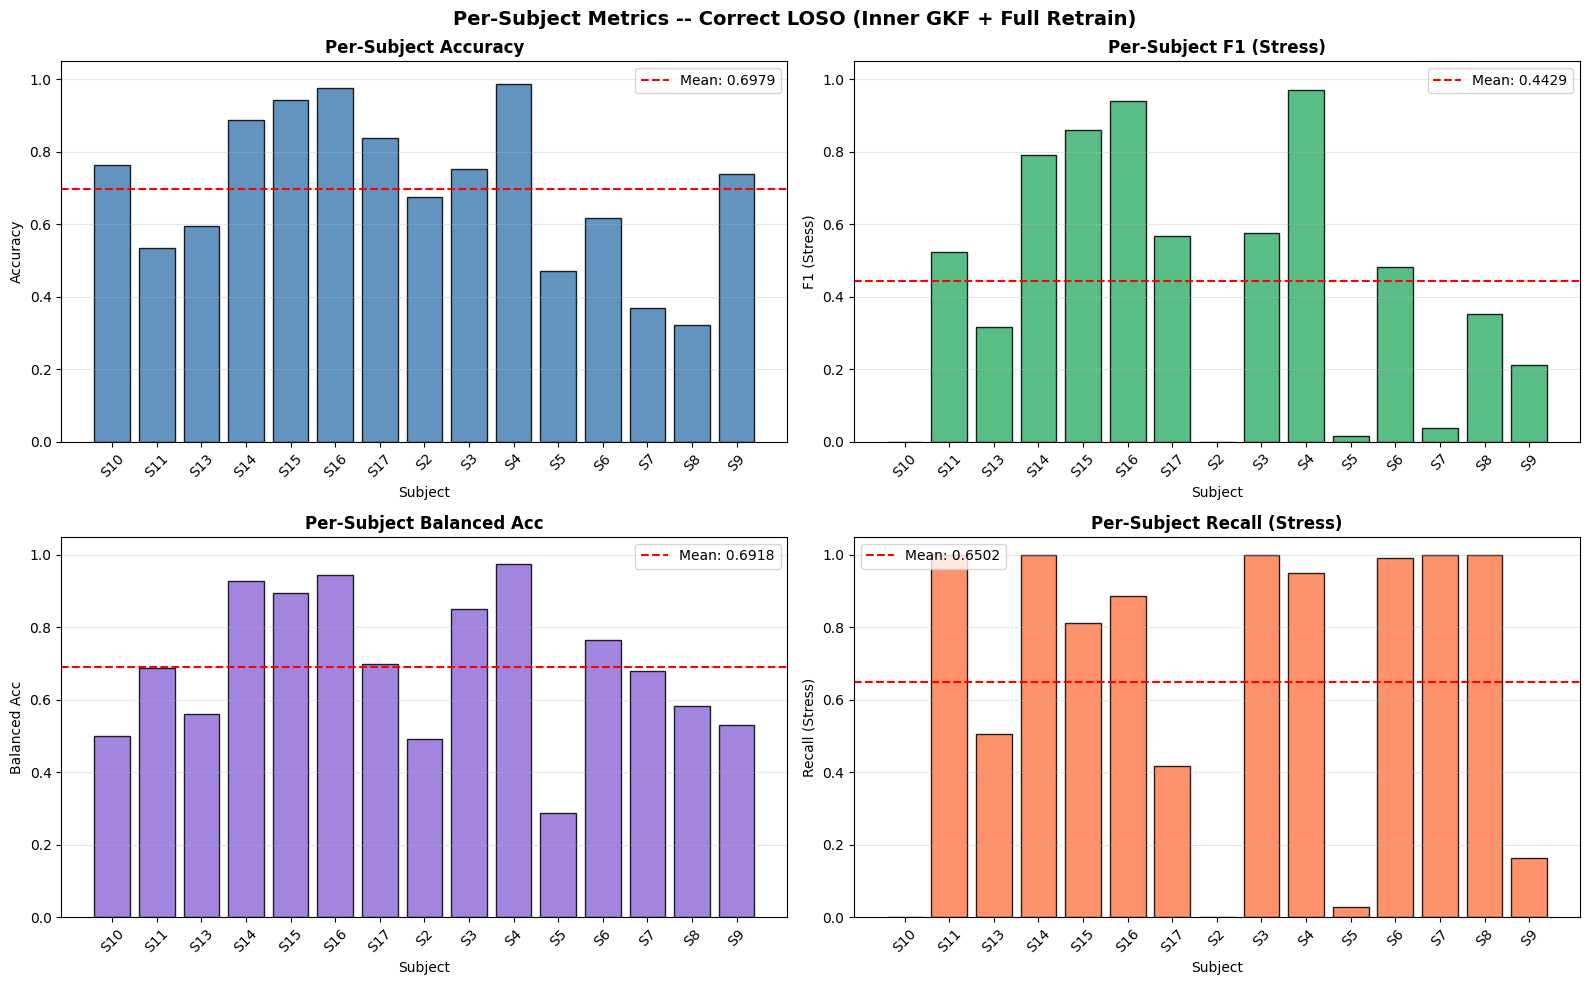

In [18]:
# STEP 8: VISUALIZATION 1 -- Per-Subject Metrics (4 panels)

output_dir = './results_fixed'
os.makedirs(output_dir, exist_ok=True)

viz_metrics = ['accuracy', 'f1', 'balanced_accuracy', 'recall_stress']
colors      = ['steelblue', 'mediumseagreen', 'mediumpurple', 'coral']
labels      = ['Accuracy', 'F1 (Stress)', 'Balanced Acc', 'Recall (Stress)']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
x = range(len(results_df))

for ax, col, color, label in zip(axes, viz_metrics, colors, labels):
    mean_val = results_df[col].mean()
    ax.bar(x, results_df[col], color=color, edgecolor='black', alpha=0.85)
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {mean_val:.4f}')
    ax.set_title(f'Per-Subject {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Subject')
    ax.set_ylabel(label)
    ax.set_xticks(list(x))
    ax.set_xticklabels(results_df['subject'].astype(str), rotation=45)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Per-Subject Metrics -- Correct LOSO (Inner GKF + Full Retrain)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/1_Per_Subject_Metrics.png', dpi=300, bbox_inches='tight')
print("Saved: 1_Per_Subject_Metrics.png")
plt.show()
